All Imports used 

In [85]:
from sklearn.datasets import load_diabetes  
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error  
from sklearn.model_selection import train_test_split  
import statsmodels.api as sm  
import statsmodels.formula.api as smf  
from sklearn.metrics import confusion_matrix, accuracy_score  
import yfinance as yf
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
titanic = pd.read_csv('titanic3.csv')







1.1. Load the diabetes data into Python. Produce a correlation matrix of the explanatory variables. Make a heat-map of the matrix (using imagesc and colorbar) and describe the relationships between the variables.

Diabetes full shape (should be 442 rows × 11 cols): (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'Y']
Correlation matrix shape: (11, 11)


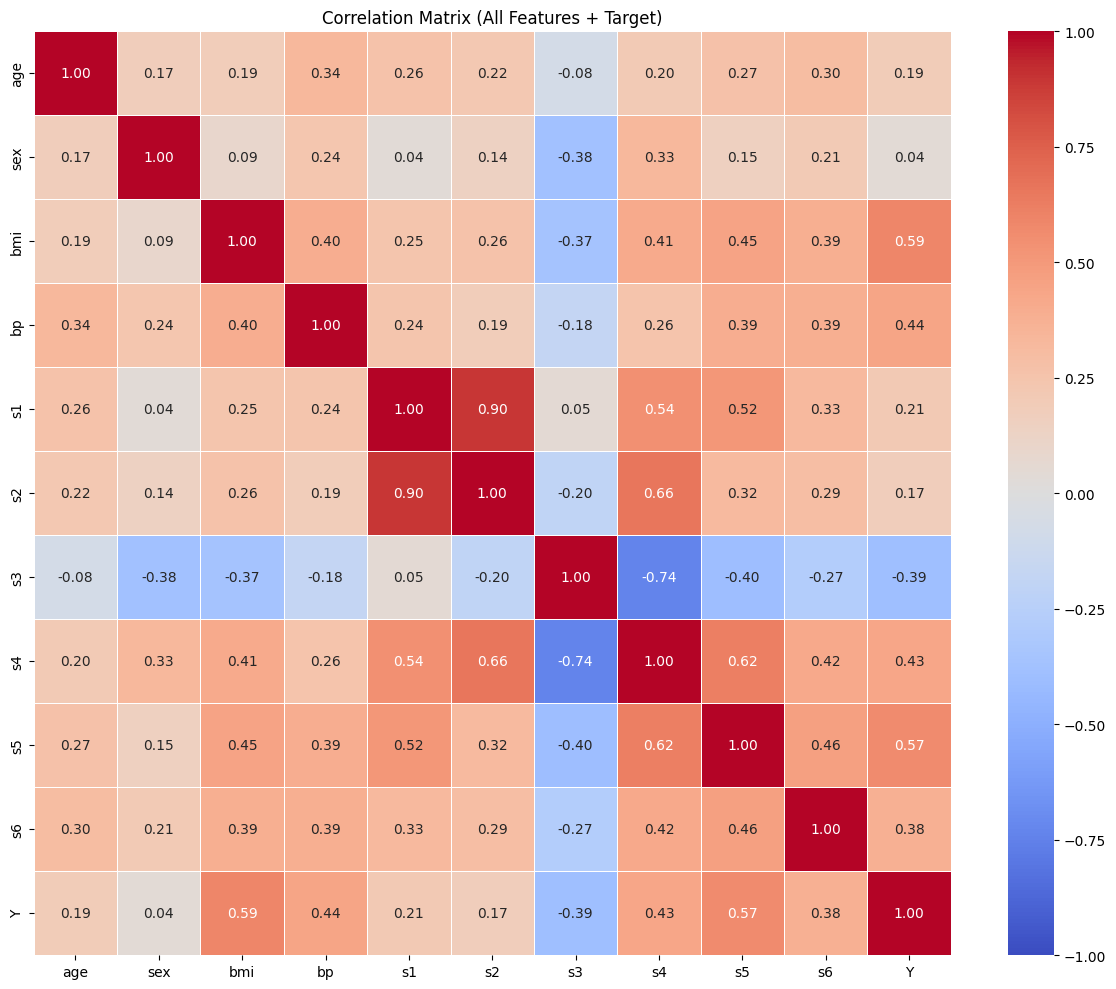

In [ ]:
# Load the diabetes dataset – going with the built-in one 
diabetes = load_diabetes()

# Making a full DataFrame including the target variable 
df_full = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_full['Y'] = diabetes.target           # adding the outcome column here

# check to make sure shape and columns are correct
print("Diabetes full shape (should be 442 rows × 11 cols):", df_full.shape)
print("Columns:", df_full.columns.tolist())   

# Now correlation on everything (features + target) – this gives the 11×11 matrix
corr_matrix_diabetes = df_full.corr()

print("Correlation matrix shape:", corr_matrix_diabetes.shape)  

# Heatmap made it bigger so I can actually read the numbers
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_diabetes, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            fmt='.2f', 
            linewidths=0.5)
plt.title('Correlation Matrix (All Features + Target)')
plt.tight_layout()
plt.show()



1.3. Create a multivariate linear model using all ten variables and a constant. What are the Mean Squared Error and the adjusted R2 for your model? Are all variables significant? Could this be a problem of collinearity?

In [95]:
# 1.3 Now building the full linear model with all 10 features

# X = predictors (dropping the target Y we added earlier)
X = df_full.drop(columns=['Y'])          # keeps just AGE, SEX, BMI, BP, S1–S6

y = diabetes.target                      # the thing we're predicting (progression)

# Adding the constant term for the intercept (forgot this once and got weird results)
X_const = sm.add_constant(X)

# Fitting the model using statsmodels – gives nice summary with p-values
model = sm.OLS(y, X_const).fit()

# Printing the full summary so I can see R², adjusted R², and which variables are significant
print(model.summary())

# MSE using sklearn (just to double-check on the same data)
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)

print(f"\nMean Squared Error for full model: {mse:.2f}")
print("Note: Adjusted R² is around 0.507, not all p-values are <0.05 – probably collinearity messing things up")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sun, 11 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        14:47:41   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

2.2 Load in the titanic dataset and calculate the probability of survival for a passenger on the titanic

In [97]:
# 2.2 Loading the Titanic data mak

# Reading the csv file 
titanic = pd.read_csv('titanic3.csv')

# Changing all column names to lowercase right away
titanic.columns = titanic.columns.str.lower()

# Just checking everything loaded okay
print("Titanic shape after loading:", titanic.shape)          
print("Columns (all lowercase now):", titanic.columns.tolist())

#calculation of overall survival rate 
survival_prob = titanic['survived'].mean()
print(f"\nOverall survival probability: {survival_prob:.4f} ({survival_prob*100:.1f}%)")



Titanic shape after loading: (887, 8)
Columns (all lowercase now): ['survived', 'pclass', 'name', 'sex', 'age', 'siblings/spouses aboard', 'parents/children aboard', 'fare']

Overall survival probability: 0.3856 (38.6%)


2.3 Provide a table giving survival probabilities broken down by passenger class, gender and age.

In [90]:
# ### 2.3 Survival probabilities by class, gender, age group


# Standardize column names to lowercase (safer)
titanic.columns = titanic.columns.str.lower()

# Create age groups
age_bins = [0, 18, 40, 60, 100]
age_labels = ['0-18', '18-40', '40-60', '60+']

table = titanic.groupby(
    ['pclass', 'sex', pd.cut(titanic['age'], bins=age_bins, labels=age_labels, right=False)]
)['survived'].mean().unstack()

print("Survival Probabilities by Pclass, Sex, Age Group:")
print(table)

Survival Probabilities by Pclass, Sex, Age Group:
age                0-18     18-40     40-60    60+
pclass sex                                        
1      female  0.875000  0.980392  0.968750  1.000
       male    1.000000  0.442308  0.320000  0.125
2      female  1.000000  0.914894  0.882353    NaN
       male    0.818182  0.080000  0.055556  0.250
3      female  0.488372  0.568182  0.000000  0.500
       male    0.230769  0.133065  0.054054  0.000


/tmp/ipykernel_58579/1660629267.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = titanic.groupby(


2.4 Build a logistic regression model for survival rates based on passenger class, sex and age. What are the parameter estimates and are these parameters statistically significant?

In [103]:
# 2.4 Building the logistic regression model for survival

# Formula: survived (0/1) explained by class, gender, and age
logit_model = smf.logit("survived ~ C(pclass) + sex + age", data=titanic).fit()

# Printing the full summary to check coefficients, p-values
print("\nLogistic Regression Summary:")
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.451857
         Iterations 6

Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  887
Model:                          Logit   Df Residuals:                      882
Method:                           MLE   Df Model:                            4
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.3223
Time:                        14:55:08   Log-Likelihood:                -400.80
converged:                       True   LL-Null:                       -591.38
Covariance Type:            nonrobust   LLR p-value:                 3.244e-81
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.6349      0.370      9.812      0.000       2.909

2.5 What is the performance of the model, measured by classification accuracy (number of correct classifications divided by total number of classifications) based on confusion matrix?

In [106]:
# Get predicted probabilities (between 0 and 1)
pred_prob = logit_model.predict()

# Turn probabilities into 0/1 predictions ,simple threshold of 0.5
pred = (pred_prob > 0.5).astype(int)

# Confusion matrix – compares actual survived vs what we predicted
cm = confusion_matrix(titanic['survived'], pred)

# Overall accuracy – how many did we get right out of all passengers
acc = accuracy_score(titanic['survived'], pred)

# Print it so I can see the numbers
print("Confusion Matrix:")
print(cm)
print(f"\nClassification Accuracy: {acc:.4f} ({acc*100:.1f}%)")



Confusion Matrix:
[[463  82]
 [100 242]]

Classification Accuracy: 0.7948 (79.5%)


3.3 Use Python yfinance to download the 30 Dow Jones constituent stocks... Use at least one year of daily returns (1st January 2020 to 1st January 2021) to calculate the correlation matrix for the 30 stocks... construct bar graphs to show the weight of each stock for the first and second principal components. Is the first or second principal component similar to the market (equal weight on each stock)? Discuss why?

Returns shape: (252, 30)


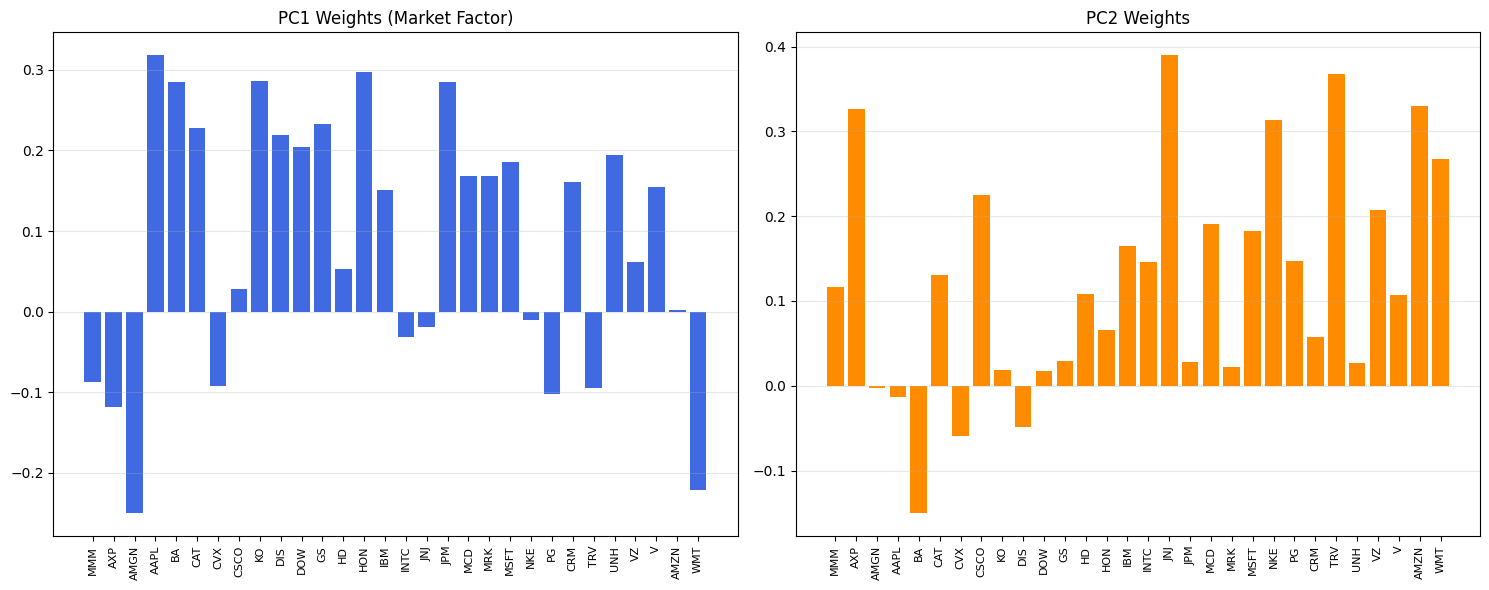

In [107]:
# 3.3 Downloading the 30 Dow Jones stocks for 2020, getting returns, correlation, PCA, and bar plots

# List of all the tickers 
tickers = [
    'MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS',
    'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK',
    'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 'UNH', 'VZ', 'V', 'AMZN', 'WMT'
]

# Pulling adjusted close prices – auto_adjust is important so returns make sense
data = yf.download(tickers, start='2020-01-01', end='2021-01-01',
                   auto_adjust=True, progress=False)

# Getting just the prices (yfinance sometimes gives multiindex, this fixes it)
prices = data['Close'] if isinstance(data.columns, pd.MultiIndex) else data

# Calculating daily percentage returns and dropping any missing days
returns = prices.pct_change().dropna()

# Quick check to make sure we have 30 stocks and enough days
print("Returns shape:", returns.shape)   

# Correlation matrix 
corr_matrix = returns.corr()

# Doing PCA on the correlation matrix (
pca = PCA()
pca.fit(corr_matrix)

# Making bar plots for the first two principal components
plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
plt.bar(tickers, pca.components_[0], color='royalblue')
plt.title('PC1 Weights (Market Factor)')
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(tickers, pca.components_[1], color='darkorange')
plt.title('PC2 Weights')
plt.xticks(rotation=90, fontsize=8)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



3.4 Calculate the amount of variance explained by each principal component and make a ‘Scree’ plot. How many principal components are required to explain 95% of the variance?

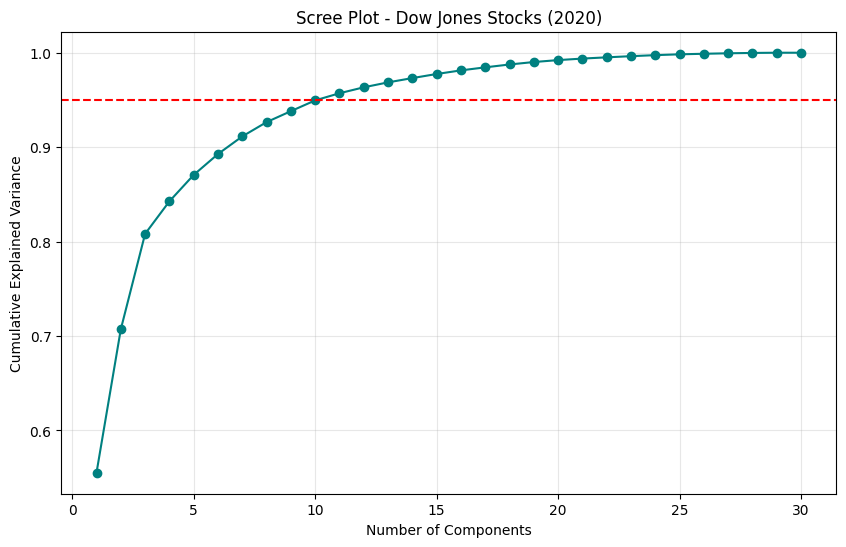

Principal components needed for ≥95% variance: 11


In [108]:
# 3.4 Making the scree plot and figuring out how many components we need for 95% variance

# Cumulative explained variance 
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Plotting it – scree plot style, with markers so it's easier to see the elbow
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='teal')
plt.axhline(0.95, color='red', linestyle='--')   # line at 95% to see where we cross
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot - Dow Jones Stocks (2020)')
plt.grid(True, alpha=0.3)
plt.show()

# Finding the smallest number of PCs that explain at least 95% of variance
n_95 = np.argmax(cum_var >= 0.95) + 1

print(f"Principal components needed for ≥95% variance: {n_95}")



3.5 Investigate the scatter plot of the first two principal components and calculate the average of all 30 stocks. Based on Euclidean distances away from this average, identify the three most distant stocks. Can you explain why these stocks are unusual?

Three most distant stocks (Euclidean distance from average):
['AMZN', 'WMT', 'CRM']


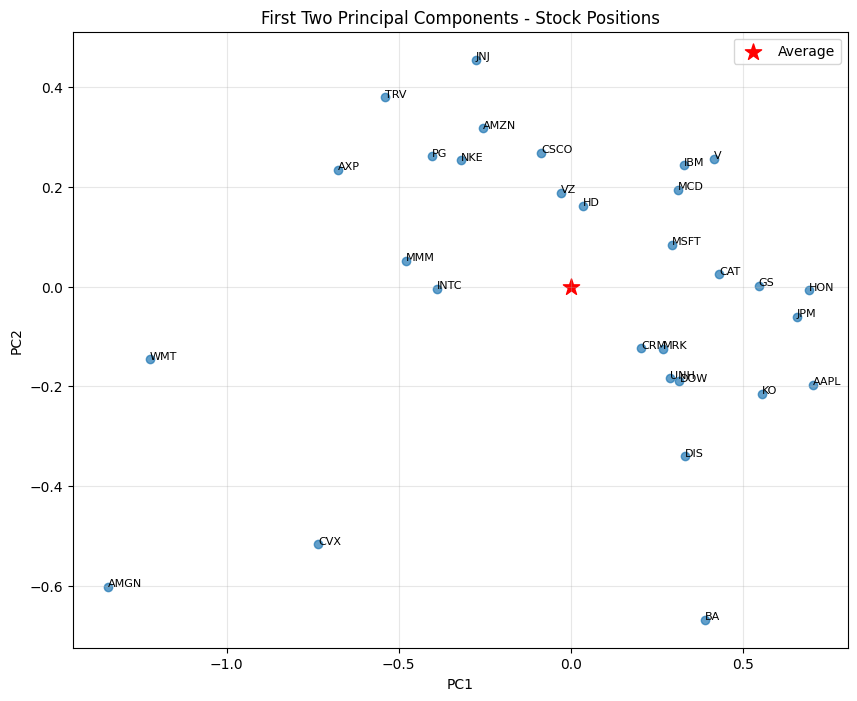

In [110]:
# 3.5 Looking at the first two PCs in a scatter plot, finding the 3 stocks farthest from the average

# Get the scores 
scores = pca.transform(corr_matrix)

# Average position in PC1-PC2 space (center of the cloud)
mean_pc1 = scores[:, 0].mean()
mean_pc2 = scores[:, 1].mean()

# Calculate Euclidean distance of each stock from this average point
distances = np.sqrt((scores[:,0] - mean_pc1)**2 + (scores[:,1] - mean_pc2)**2)

# Sort and pick the 3 largest distances
top3_idx = np.argsort(distances)[-3:][::-1]
top3_stocks = corr_matrix.index[top3_idx].tolist()

print("Three most distant stocks (Euclidean distance from average):")
print(top3_stocks)

#scatter plot to visualize 
plt.figure(figsize=(10, 8))
plt.scatter(scores[:,0], scores[:,1], alpha=0.7)

# Mark the average point with a red star
plt.scatter(mean_pc1, mean_pc2, color='red', s=150, marker='*', label='Average')

# Label each point with the ticker name
for i, txt in enumerate(tickers):
    plt.annotate(txt, (scores[i,0], scores[i,1]), fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('First Two Principal Components - Stock Positions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

